**Level 2 – Task 2: Time Series Analysis**

In this task, time series analysis is performed on stock price data to identify trends, patterns, and seasonal variations over time using visualization, moving averages, and decomposition techniques.

**Data Loading**

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://drive.google.com/uc?export=download&id=1HQQa-fPovsiaRwML9V-A6_35x0xdATyz"
df = pd.read_csv(url)

df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


**Converted date column**

In [26]:
df.columns = df.columns.str.strip()
df['date'] = pd.to_datetime(df['date'])

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497472 non-null  object        
 1   date    497472 non-null  datetime64[ns]
 2   open    497461 non-null  float64       
 3   high    497464 non-null  float64       
 4   low     497464 non-null  float64       
 5   close   497472 non-null  float64       
 6   volume  497472 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 26.6+ MB


**Selected AAPL Stock**

In [28]:
aapl = df[df['symbol'] == 'AAPL']

**Sorted and set date Index**

In [29]:
aapl = aapl.sort_values('date')
aapl.set_index('date', inplace=True)

**Removed missing values**

In [30]:
aapl = aapl.dropna()

**Plotted Time Series**

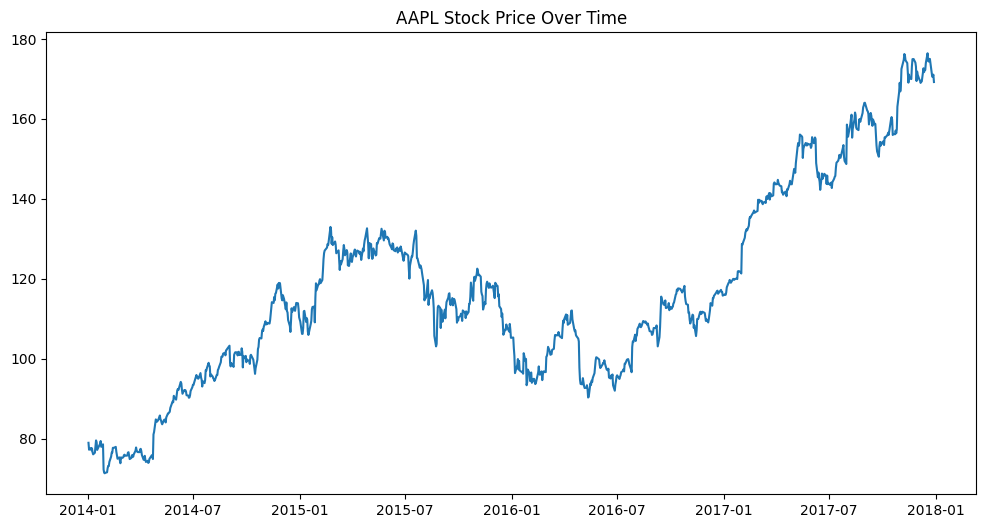

In [31]:
plt.figure(figsize=(12,6))
plt.plot(aapl['close'])
plt.title("AAPL Stock Price Over Time")
plt.show()

**Applied Moving Average**

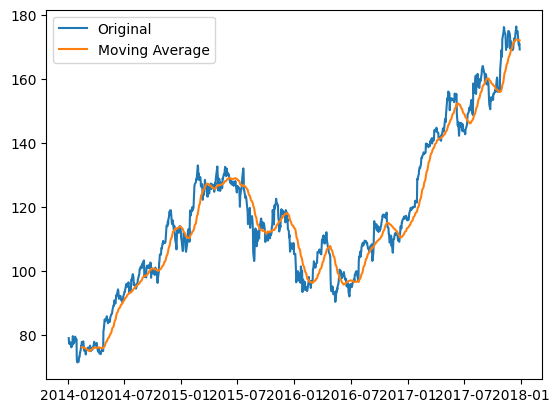

In [32]:
aapl['MA_30'] = aapl['close'].rolling(30).mean()

plt.plot(aapl['close'], label='Original')
plt.plot(aapl['MA_30'], label='Moving Average')
plt.legend()
plt.show()

**Performed Decomposition**

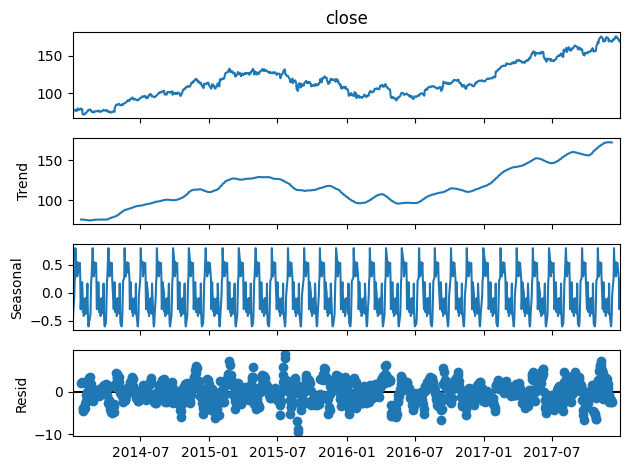

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(aapl['close'], model='additive', period=30)
result.plot()
plt.show()

**CONCLUSION**

The time series analysis of AAPL stock data shows that stock prices vary over time with visible trends. The moving average helps in smoothing short-term fluctuations and provides a clearer view of the overall trend. Decomposition separates the data into trend, seasonal, and residual components, allowing better understanding of patterns in stock prices.